# News Recommendation System — Simulation
**Commodity Trading Platform (Vanijyaa)**

This notebook simulates the full news recommendation pipeline:
1. Synthetic news generation (1000 articles/day)
2. Classification into 10 clusters
3. Scope & region tagging
4. Role-based + scope-based + region-based scoring
5. Two-section feed: Breaking + For You
6. Interactive query: pick a role, scope, state, commodities → get your feed

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print("Ready.")

Ready.


## 1. System Constants
All 10 clusters, role weights, scope multipliers, region mappings — exactly as designed.

In [38]:
# ── 10 Clusters with per-role weights ──
CLUSTERS = {
    1:  {"name": "Policy & Regulation",              "trader": 15.0, "broker": 9.2, "exporter": 9.8},
    2:  {"name": "Geopolitical & Macro Shocks",       "trader": 8.7, "broker": 8.4, "exporter": 9.5},
    3:  {"name": "Supply-side Disruptions",           "trader": 7.3, "broker": 9.0, "exporter": 8.8},
    4:  {"name": "Financial & Market Mechanics",      "trader": 5.8, "broker": 6.8, "exporter": 7.5},
    5:  {"name": "Structural & Industrial Shifts",    "trader": 4.2, "broker": 6.2, "exporter": 6.8},
    6:  {"name": "Long-term Demand Trends",           "trader": 3.2, "broker": 4.5, "exporter": 5.8},
    7:  {"name": "Market Participation & Deal Flow",  "trader": 6.5, "broker": 9.3, "exporter": 7.2},
    8:  {"name": "Price Volatility & Sentiment",      "trader": 8.5, "broker": 9.0, "exporter": 7.0},
    9:  {"name": "Local Operational Events",          "trader": 5.5, "broker": 8.5, "exporter": 6.8},
    10: {"name": "Indirect / General News",           "trader": 4.5, "broker": 5.5, "exporter": 5.8},
}

# ── Scope multiplier: user_scope x news_scope ──
SCOPE_MULTIPLIER = {
    "local":         {"local": 3.0, "state": 2.0, "national": 1.0, "global": 0.5},
    "regional":      {"local": 1.5, "state": 2.5, "national": 1.5, "global": 0.7},
    "national":      {"local": 0.7, "state": 1.0, "national": 2.5, "global": 1.5},
    "international": {"local": 0.3, "state": 0.5, "national": 1.5, "global": 3.0},
}

# ── State neighbors ──
STATE_NEIGHBORS = {
    "Maharashtra":    ["Gujarat", "Karnataka", "Telangana", "Goa", "Madhya Pradesh"],
    "Gujarat":        ["Maharashtra", "Rajasthan", "Madhya Pradesh"],
    "Karnataka":      ["Maharashtra", "Goa", "Kerala", "Tamil Nadu", "Telangana", "Andhra Pradesh"],
    "Tamil Nadu":     ["Karnataka", "Kerala", "Andhra Pradesh"],
    "Uttar Pradesh":  ["Madhya Pradesh", "Rajasthan", "Bihar", "Uttarakhand", "Haryana"],
    "Madhya Pradesh": ["Maharashtra", "Gujarat", "Rajasthan", "Uttar Pradesh", "Chhattisgarh"],
    "Rajasthan":      ["Gujarat", "Madhya Pradesh", "Uttar Pradesh", "Haryana", "Punjab"],
    "Punjab":         ["Rajasthan", "Haryana", "Himachal Pradesh"],
    "Haryana":        ["Punjab", "Rajasthan", "Uttar Pradesh", "Delhi"],
    "West Bengal":    ["Bihar", "Odisha", "Jharkhand"],
    "Andhra Pradesh": ["Telangana", "Karnataka", "Tamil Nadu", "Odisha"],
    "Telangana":      ["Maharashtra", "Karnataka", "Andhra Pradesh", "Chhattisgarh"],
    "Kerala":         ["Karnataka", "Tamil Nadu"],
    "Bihar":          ["Uttar Pradesh", "West Bengal", "Jharkhand"],
    "Odisha":         ["West Bengal", "Andhra Pradesh", "Chhattisgarh"],
}

INDIAN_STATES = list(STATE_NEIGHBORS.keys())
COMMODITIES = ["rice", "sugar", "cotton", "wheat", "soybean", "jute", "tea", "coffee"]
NEWS_SCOPES = ["local", "state", "national", "global"]
ROLES = ["trader", "broker", "exporter"]
TRADER_SCOPES = ["local", "regional", "national", "international"]

# ── Breaking news bypass: clusters 1-2 with severity > 8 ──
BREAKING_CLUSTERS = {1, 2}
BREAKING_SEVERITY_THRESHOLD = 7.0

print(f"10 clusters | {len(INDIAN_STATES)} states | {len(COMMODITIES)} commodities")
print(f"Scope multiplier: {len(SCOPE_MULTIPLIER)}x{len(NEWS_SCOPES)} matrix")

10 clusters | 15 states | 8 commodities
Scope multiplier: 4x4 matrix


## 2. Synthetic News Generator
Generates ~1000 realistic articles with proper cluster/scope/region distributions.

In [39]:
# ── Headline templates per cluster ──
HEADLINES = {
    1: [
        "Government {action} {commodity} export {policy}",
        "New MSP announced for {commodity} at Rs {price}/quintal",
        "FSSAI tightens quality norms for {commodity} exports",
        "{state} government announces {commodity} procurement policy",
        "DGFT issues notification on {commodity} import duty revision",
    ],
    2: [
        "INR weakens to {rate} against USD amid global uncertainty",
        "Global recession fears hit {commodity} demand forecasts",
        "War disrupts {commodity} supply routes from {country}",
        "Federal Reserve rate decision impacts {commodity} futures",
        "China's economic slowdown reduces {commodity} imports",
    ],
    3: [
        "Monsoon deficit hits {percent}% in {state} — {commodity} at risk",
        "Shipping delays at {port} port affect {commodity} exports",
        "Labour strike in {state} {commodity} mills enters day {days}",
        "Flood damage to {commodity} crops in {state} estimated at Rs {amount} crore",
        "Cyclone warning issued for {state} coast — {commodity} logistics halted",
    ],
    4: [
        "NCDEX raises {commodity} futures margin by {percent}%",
        "Credit tightening hits {commodity} traders in {state}",
        "Inventory restocking drives {commodity} spot price rally",
        "Insurance premiums for {commodity} storage rise {percent}%",
        "RBI policy impacts agricultural lending rates",
    ],
    5: [
        "New textile park in {state} to boost {commodity} demand",
        "Yield improvement technology adopted in {state} for {commodity}",
        "Major {commodity} processing merger announced",
        "Cold chain infrastructure expansion in {state}",
        "AgriTech startup raises funding for {commodity} supply chain",
    ],
    6: [
        "Urban consumption of {commodity} rises {percent}% YoY",
        "Health-conscious consumers shift demand patterns for {commodity}",
        "Environmental regulation may impact {commodity} farming in {state}",
        "Organic {commodity} demand grows {percent}% in metro cities",
        "Climate change projections for {commodity} belt in {state}",
    ],
    7: [
        "{commodity} mandi arrivals up {percent}% in {state}",
        "New buyers enter {commodity} market in {state}",
        "Record {commodity} deal flow at {state} APMC",
        "Digital platform adoption rises among {commodity} traders in {state}",
        "Cross-state {commodity} trade volumes surge {percent}%",
    ],
    8: [
        "{commodity} prices surge {percent}% on {state} supply concerns",
        "Bearish sentiment in {commodity} futures — open interest drops",
        "{commodity} spot vs futures spread widens to Rs {price}",
        "Market sentiment turns bullish on {commodity} after {event}",
        "Volatile week for {commodity} — weekly range of {percent}%",
    ],
    9: [
        "{state} mandi closure due to local festival — {commodity} affected",
        "Power outage disrupts {commodity} cold storage in {city}",
        "Local transport strike impacts {commodity} arrivals in {state}",
        "Municipal regulation change affects {commodity} warehousing in {city}",
        "Water shortage hits {commodity} processing units in {state}",
    ],
    10: [
        "Agricultural GDP growth revised to {percent}% for FY26",
        "Budget allocation for agriculture ministry increases {percent}%",
        "Global food security report highlights {commodity} trends",
        "Rural employment data shows shift from {commodity} farming",
        "New agricultural education initiative launched in {state}",
    ],
}

COUNTRIES = ["Ukraine", "Russia", "Brazil", "Thailand", "Vietnam", "Australia"]
PORTS = ["Mumbai", "Kandla", "Chennai", "Kolkata", "Mundra", "Visakhapatnam"]
CITIES = ["Pune", "Nashik", "Nagpur", "Ahmedabad", "Indore", "Jaipur", "Ludhiana",
          "Coimbatore", "Lucknow", "Kolkata", "Hyderabad", "Bengaluru"]
EVENTS = ["monsoon forecast", "govt policy change", "global demand surge", "currency move"]

def gen_headline(cluster_id):
    template = random.choice(HEADLINES[cluster_id])
    return template.format(
        commodity=random.choice(COMMODITIES),
        state=random.choice(INDIAN_STATES),
        action=random.choice(["bans", "restricts", "liberalizes", "reviews"]),
        policy=random.choice(["ban", "quota", "tariff", "subsidy"]),
        price=random.randint(1500, 8000),
        rate=round(random.uniform(85, 90), 1),
        country=random.choice(COUNTRIES),
        percent=random.randint(3, 40),
        port=random.choice(PORTS),
        days=random.randint(3, 15),
        amount=random.randint(50, 5000),
        city=random.choice(CITIES),
        event=random.choice(EVENTS),
    )

def gen_severity(cluster_id):
    base = {1: 9.0, 2: 8.5, 3: 7.5, 4: 6.0, 5: 4.5, 6: 3.5, 7: 6.0, 8: 8.0, 9: 5.5, 10: 4.0}
    return round(np.clip(base[cluster_id] + np.random.normal(0, 0.8), 1, 10), 1)

def gen_scope(cluster_id):
    weights = {
        1: [0.05, 0.15, 0.60, 0.20], 2: [0.02, 0.05, 0.30, 0.63],
        3: [0.15, 0.35, 0.35, 0.15], 4: [0.05, 0.10, 0.55, 0.30],
        5: [0.10, 0.30, 0.45, 0.15], 6: [0.05, 0.10, 0.40, 0.45],
        7: [0.30, 0.40, 0.25, 0.05], 8: [0.10, 0.20, 0.50, 0.20],
        9: [0.50, 0.35, 0.10, 0.05], 10:[0.10, 0.15, 0.50, 0.25],
    }
    return np.random.choice(NEWS_SCOPES, p=weights[cluster_id])

def gen_regions(scope, cluster_id):
    if scope == "local":
        return [random.choice(INDIAN_STATES)]
    elif scope == "state":
        s = random.choice(INDIAN_STATES)
        return [s] + random.sample(STATE_NEIGHBORS.get(s, [])[:2], min(1, len(STATE_NEIGHBORS.get(s, []))))
    elif scope == "national":
        return ["India"] + random.sample(INDIAN_STATES, random.randint(0, 2))
    else:
        return [random.choice(COUNTRIES)] + (["India"] if random.random() > 0.4 else [])

def gen_commodities(cluster_id):
    n = 1 if cluster_id in [9, 10] else random.choice([1, 1, 1, 2])
    return random.sample(COMMODITIES, n)

def gen_role_impact(cluster_id):
    impacts = {}
    for role in ROLES:
        w = CLUSTERS[cluster_id][role]
        if w >= 7.5: impacts[role] = "high"
        elif w >= 5.0: impacts[role] = "medium"
        else: impacts[role] = "low"
    return impacts

def generate_news(n=1000, hours=24):
    articles = []
    cluster_weights = [0.12, 0.08, 0.10, 0.08, 0.06, 0.05, 0.12, 0.15, 0.14, 0.10]
    now = datetime.now()
    for i in range(n):
        cluster_id = np.random.choice(range(1, 11), p=cluster_weights)
        scope = gen_scope(cluster_id)
        regions = gen_regions(scope, cluster_id)
        commodities = gen_commodities(cluster_id)
        impacts = gen_role_impact(cluster_id)
        published = now - timedelta(hours=random.uniform(0, hours))
        articles.append({
            "id": f"NEWS-{i+1:04d}",
            "title": gen_headline(cluster_id),
            "cluster_id": int(cluster_id),
            "cluster_name": CLUSTERS[cluster_id]["name"],
            "severity": gen_severity(cluster_id),
            "news_scope": scope,
            "regions": regions,
            "commodities": commodities,
            "trader_impact": impacts["trader"],
            "broker_impact": impacts["broker"],
            "exporter_impact": impacts["exporter"],
            "published_at": published,
            "hours_ago": round((now - published).total_seconds() / 3600, 1),
        })
    return pd.DataFrame(articles)

news_df = generate_news(1000)
print(f"Generated {len(news_df)} articles across 10 clusters")
print(f"\nCluster distribution:")
print(news_df.groupby(['cluster_id','cluster_name']).size().reset_index(name='count').to_string(index=False))

Generated 1000 articles across 10 clusters

Cluster distribution:
 cluster_id                     cluster_name  count
          1              Policy & Regulation    109
          2      Geopolitical & Macro Shocks     89
          3          Supply-side Disruptions     98
          4     Financial & Market Mechanics     80
          5   Structural & Industrial Shifts     69
          6          Long-term Demand Trends     49
          7 Market Participation & Deal Flow    114
          8     Price Volatility & Sentiment    141
          9         Local Operational Events    143
         10          Indirect / General News    108


## 3. Scoring Engine
The core recommendation formula with all multipliers: role weight × commodity match × scope match × region match.

In [40]:
def compute_feed_score(article, user_role, user_scope, user_state, user_commodities):
    cluster_id = article["cluster_id"]
    severity = article["severity"]

    # 1. Role weight from cluster table
    role_weight = CLUSTERS[cluster_id][user_role]

    # 2. Commodity match
    article_commodities = article["commodities"]
    commodity_match = 2.0 if any(c in user_commodities for c in article_commodities) else 1.0

    # 3. Scope match (bypass for breaking news)
    is_breaking = cluster_id in BREAKING_CLUSTERS and severity >= BREAKING_SEVERITY_THRESHOLD
    if is_breaking:
        scope_match = 1.0
        region_match = 1.0
    else:
        scope_match = SCOPE_MULTIPLIER.get(user_scope, {}).get(article["news_scope"], 1.0)
        # 4. Region match
        article_regions = article["regions"]
        neighbors = STATE_NEIGHBORS.get(user_state, [])
        if user_state in article_regions:
            region_match = 2.0
        elif any(n in article_regions for n in neighbors):
            region_match = 1.3
        else:
            region_match = 1.0

    feed_score = severity * role_weight * commodity_match * scope_match * region_match
    return {
        "feed_score": round(feed_score, 1),
        "role_weight": role_weight,
        "commodity_match": commodity_match,
        "scope_match": scope_match,
        "region_match": region_match,
        "is_breaking": is_breaking,
    }


def get_feed(news_df, user_role, user_scope, user_state, user_commodities, limit=30):
    scored = []
    for _, article in news_df.iterrows():
        scores = compute_feed_score(article, user_role, user_scope, user_state, user_commodities)
        row = {**article.to_dict(), **scores}
        scored.append(row)

    scored_df = pd.DataFrame(scored)
    feed = scored_df.sort_values("feed_score", ascending=False).head(limit)

    return feed, scored_df

print("Scoring engine ready.")

Scoring engine ready.


## 4. Feed Display
Formatted output showing both sections with score breakdown.

In [41]:
def display_feed( for_you, user_role, user_scope, user_state, user_commodities):
    print("=" * 90)
    print(f"  NEWS FEED for: {user_role.upper()} | scope: {user_scope} | state: {user_state}")
    print(f"  commodities: {', '.join(user_commodities)}")
    print("=" * 90)

    # For You section
    print(f"\n{'─' * 90}")
    print(f"  📰 FOR YOU ({len(for_you)} articles)")
    print(f"{'─' * 90}")
    for i, (_, row) in enumerate(for_you.iterrows()):
        if i >= 15:
            print(f"\n  ... and {len(for_you) - 15} more articles")
            break
        commodity_tag = ", ".join(row["commodities"])
        scope_badge = f"scope:{row['scope_match']}x" if row["scope_match"] != 1.0 else ""
        region_badge = f"region:{row['region_match']}x" if row["region_match"] != 1.0 else ""
        comm_badge = f"comm:{row['commodity_match']}x" if row["commodity_match"] > 1.0 else ""
        badges = " | ".join(filter(None, [scope_badge, region_badge, comm_badge]))

        print(f"\n  #{i+1} [score: {row['feed_score']}] [{row['cluster_name']}]")
        print(f"  {row['title']}")
        print(f"  severity: {row['severity']} | {row['news_scope']} | {commodity_tag} | {row['hours_ago']}h ago")
        if badges:
            print(f"  boosts: {badges}")

print("Display function ready.")

Display function ready.


## 5. Run the Simulation
Change the user profile below and re-run to see how the feed changes.

In [42]:
# ════════════════════════════════════════════════════════
#  CHANGE THESE to simulate different users
# ════════════════════════════════════════════════════════

USER_ROLE        = "exporter"           # trader | broker | exporter
USER_SCOPE       = "international"            # local | regional | national | international
USER_STATE       = "Maharashtra"      # any Indian state from STATE_NEIGHBORS
USER_COMMODITIES = ["rice", "cotton"] # pick from COMMODITIES list

# ════════════════════════════════════════════════════════

for_you, all_scored = get_feed(
    news_df, USER_ROLE, USER_SCOPE, USER_STATE, USER_COMMODITIES
)

display_feed(for_you, USER_ROLE, USER_SCOPE, USER_STATE, USER_COMMODITIES)

  NEWS FEED for: EXPORTER | scope: international | state: Maharashtra
  commodities: rice, cotton

──────────────────────────────────────────────────────────────────────────────────────────
  📰 FOR YOU (30 articles)
──────────────────────────────────────────────────────────────────────────────────────────

  #1 [score: 454.1] [Supply-side Disruptions]
  Monsoon deficit hits 3% in Kerala — coffee at risk
  severity: 8.6 | global | cotton | 5.5h ago
  boosts: scope:3.0x | comm:2.0x

  #2 [score: 406.6] [Supply-side Disruptions]
  Flood damage to sugar crops in Kerala estimated at Rs 3561 crore
  severity: 7.7 | global | soybean, cotton | 3.3h ago
  boosts: scope:3.0x | comm:2.0x

  #3 [score: 373.8] [Price Volatility & Sentiment]
  rice spot vs futures spread widens to Rs 2664
  severity: 8.9 | global | cotton | 5.8h ago
  boosts: scope:3.0x | comm:2.0x

  #4 [score: 359.0] [Supply-side Disruptions]
  Flood damage to rice crops in Madhya Pradesh estimated at Rs 2124 crore
  severity: 6.8

## 6. Compare: Same News, Different Roles
See how the same articles rank differently for a trader vs broker vs exporter.

In [43]:
print(f"{'─' * 90}")
print(f"  Comparing top 10 articles for each role")
print(f"  scope: local | state: Maharashtra | commodities: rice, cotton")
print(f"{'─' * 90}")

for role in ["trader", "broker", "exporter"]:
    for_you, _ = get_feed(news_df, role, "local", "Maharashtra", ["rice", "cotton"])
    combined = pd.concat([for_you]).head(10)
    print(f"\n  ▸ {role.upper()} top 10:")
    for i, (_, row) in enumerate(combined.iterrows()):
        brk = " ⚡" if row["is_breaking"] else ""
        print(f"    {i+1}. [{row['feed_score']:>7.1f}] {row['cluster_name'][:30]:30s} | {row['title'][:50]}{brk}")

──────────────────────────────────────────────────────────────────────────────────────────
  Comparing top 10 articles for each role
  scope: local | state: Maharashtra | commodities: rice, cotton
──────────────────────────────────────────────────────────────────────────────────────────

  ▸ TRADER top 10:
    1. [  578.0] Price Volatility & Sentiment   | wheat spot vs futures spread widens to Rs 4780
    2. [  557.6] Price Volatility & Sentiment   | Volatile week for jute — weekly range of 27%
    3. [  543.7] Price Volatility & Sentiment   | Volatile week for jute — weekly range of 15%
    4. [  530.4] Price Volatility & Sentiment   | Market sentiment turns bullish on wheat after glob
    5. [  477.4] Price Volatility & Sentiment   | coffee prices surge 17% on Bihar supply concerns
    6. [  455.5] Supply-side Disruptions        | Shipping delays at Mundra port affect tea exports
    7. [  438.6] Price Volatility & Sentiment   | Market sentiment turns bullish on cotton after gov
    

## 7. Compare: Local vs International Trader
Same role (trader), same commodities — but local vs international scope.

In [44]:
print(f"{'─' * 90}")
print(f"  Local trader vs International trader — same commodities (rice, sugar)")
print(f"{'─' * 90}")

for scope in ["local", "international"]:
    for_you, _ = get_feed(news_df, "trader", scope, "Maharashtra", ["rice", "sugar"])
    top5 = for_you.head(5)
    print(f"\n  ▸ {scope.upper()} trader:")
    for i, (_, row) in enumerate(top5.iterrows()):
        print(f"    {i+1}. [{row['feed_score']:>7.1f}] scope:{row['news_scope']:10s} | {row['title'][:60]}")

──────────────────────────────────────────────────────────────────────────────────────────
  Local trader vs International trader — same commodities (rice, sugar)
──────────────────────────────────────────────────────────────────────────────────────────

  ▸ LOCAL trader:
    1. [  578.0] scope:state      | wheat spot vs futures spread widens to Rs 4780
    2. [  561.6] scope:local      | Record tea deal flow at Maharashtra APMC
    3. [  543.7] scope:local      | Volatile week for jute — weekly range of 15%
    4. [  530.4] scope:local      | Market sentiment turns bullish on wheat after global demand 
    5. [  477.4] scope:local      | coffee prices surge 17% on Bihar supply concerns

  ▸ INTERNATIONAL trader:
    1. [  448.8] scope:global     | Bearish sentiment in tea futures — open interest drops
    2. [  423.3] scope:global     | soybean prices surge 27% on Odisha supply concerns
    3. [  402.9] scope:global     | cotton spot vs futures spread widens to Rs 3696
    4. [  397.8

## 8. Feed Analytics
Distribution analysis of the scored feed.

In [45]:
!pip install matplotlib seaborn --quiet

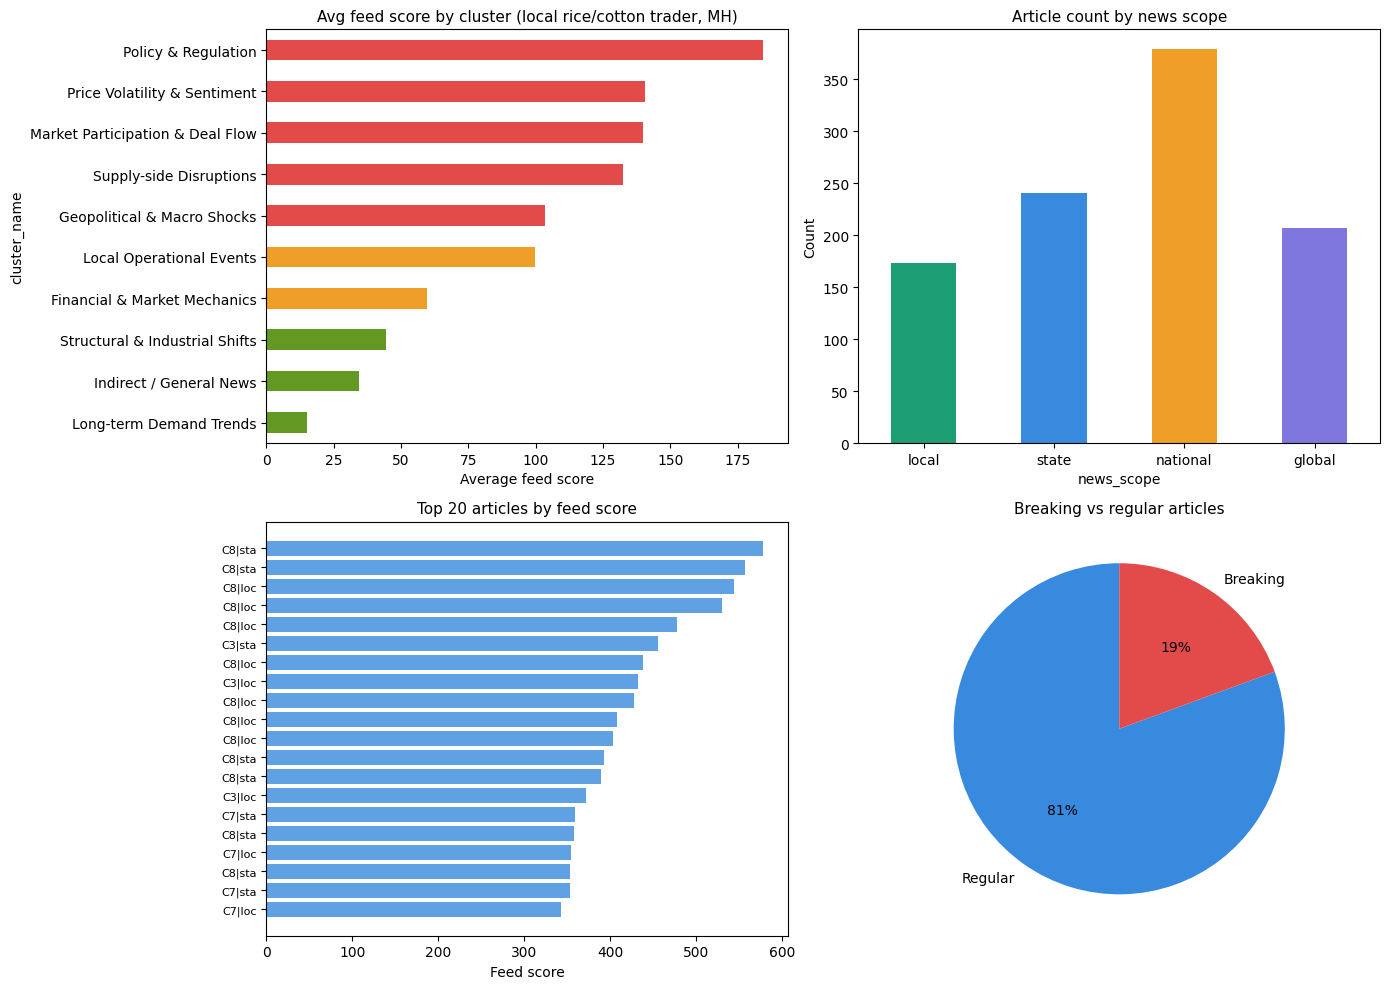


Breaking articles: 194 | Regular: 806
Average feed score — Breaking: 148.7 | Regular: 94.0


In [46]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'

_, all_scored = get_feed(news_df, "trader", "local", "Maharashtra", ["rice", "cotton"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distribution by cluster
ax = axes[0, 0]
cluster_scores = all_scored.groupby("cluster_name")["feed_score"].mean().sort_values(ascending=True)
colors = ['#E24B4A' if v > 100 else '#EF9F27' if v > 50 else '#639922' for v in cluster_scores.values]
cluster_scores.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Avg feed score by cluster (local rice/cotton trader, MH)", fontsize=11)
ax.set_xlabel("Average feed score")

# 2. Scope distribution in feed
ax = axes[0, 1]
scope_counts = all_scored.groupby("news_scope").size()
scope_order = ["local", "state", "national", "global"]
scope_counts = scope_counts.reindex(scope_order, fill_value=0)
scope_counts.plot(kind='bar', ax=ax, color=['#1D9E75', '#378ADD', '#EF9F27', '#7F77DD'])
ax.set_title("Article count by news scope", fontsize=11)
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)

# 3. Top 20 articles score breakdown
ax = axes[1, 0]
top20 = all_scored.sort_values("feed_score", ascending=False).head(20)
y_pos = range(len(top20))
ax.barh(y_pos, top20["feed_score"].values, color='#378ADD', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"C{r['cluster_id']}|{r['news_scope'][:3]}" for _, r in top20.iterrows()], fontsize=8)
ax.set_title("Top 20 articles by feed score", fontsize=11)
ax.set_xlabel("Feed score")
ax.invert_yaxis()

# 4. Breaking vs regular distribution
ax = axes[1, 1]
breaking_counts = all_scored["is_breaking"].value_counts()
labels = ["Regular", "Breaking"]
colors_pie = ['#378ADD', '#E24B4A']
vals = [breaking_counts.get(False, 0), breaking_counts.get(True, 0)]
ax.pie(vals, labels=labels, colors=colors_pie, autopct='%1.0f%%', startangle=90)
ax.set_title("Breaking vs regular articles", fontsize=11)

plt.tight_layout()
plt.savefig("feed_analytics.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"\nBreaking articles: {vals[1]} | Regular: {vals[0]}")
print(f"Average feed score — Breaking: {all_scored[all_scored['is_breaking']]['feed_score'].mean():.1f} | Regular: {all_scored[~all_scored['is_breaking']]['feed_score'].mean():.1f}")

## 9. Interactive Feed Explorer
Use the dropdowns below to simulate any user profile and see their personalized feed.

In [47]:
# !pip install wordcloud ipywidgets --quiet

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    role_w = widgets.Dropdown(options=ROLES, value="trader", description="Role:")
    scope_w = widgets.Dropdown(options=TRADER_SCOPES, value="local", description="Scope:")
    state_w = widgets.Dropdown(options=sorted(INDIAN_STATES), value="Maharashtra", description="State:")
    comm_w = widgets.SelectMultiple(options=COMMODITIES, value=["rice", "cotton"],
                                     description="Commodities:", rows=5)
    btn = widgets.Button(description="Get My Feed", button_style='success')
    output = widgets.Output()

    def on_click(b):
        with output:
            clear_output()
            for_you, _ = get_feed(
                news_df, role_w.value, scope_w.value, state_w.value, list(comm_w.value)
            )
            display_feed(for_you, role_w.value, scope_w.value, state_w.value, list(comm_w.value))

    btn.on_click(on_click)
    display(widgets.HBox([role_w, scope_w, state_w]))
    display(comm_w)
    display(btn)
    display(output)
    print("Interactive mode ready — select options and click 'Get My Feed'")

except ImportError:
    print("ipywidgets not available. Use Cell 5 above to change user profile manually.")

SelectMultiple(description='Commodities:', index=(0, 2), options=('rice', 'sugar', 'cotton', 'wheat', 'soybean…

Button(button_style='success', description='Get My Feed', style=ButtonStyle())

Output()

Interactive mode ready — select options and click 'Get My Feed'


## 10. Production SQL Equivalent
This is the actual query that would run in your backend — what this notebook simulates.

In [ ]:
sql = '''
-- Breaking section
SELECT id, raw_title, bullet_points, cluster_id, severity,
       commodities, regions, news_scope, published_at
FROM news_articles
WHERE published_at > NOW() - INTERVAL '24 hours'
  AND cluster_id IN (1, 2)
  AND severity >= 7.0
ORDER BY severity DESC
LIMIT 5;

-- For You section (parameterized)
-- $1 = user commodities array, $2 = user_scope, $3 = user_state, $4 = neighbor_states
SELECT id, raw_title, bullet_points, cluster_id, severity,
       commodities, regions, news_scope, published_at,

       -- Role weight (swap column name based on user role)
       severity
       * {user_role}_impact_weight

       -- Commodity match
       * CASE WHEN commodities && $1 THEN 2 ELSE 1 END

       -- Scope match
       * CASE
           WHEN $2 = 'local' AND news_scope = 'local' THEN 3.0
           WHEN $2 = 'local' AND news_scope = 'state' THEN 2.0
           WHEN $2 = 'local' AND news_scope = 'national' THEN 1.0
           WHEN $2 = 'local' AND news_scope = 'global' THEN 0.5
           WHEN $2 = 'regional' AND news_scope = 'local' THEN 1.5
           WHEN $2 = 'regional' AND news_scope = 'state' THEN 2.5
           WHEN $2 = 'regional' AND news_scope = 'national' THEN 1.5
           WHEN $2 = 'regional' AND news_scope = 'global' THEN 0.7
           WHEN $2 = 'national' AND news_scope = 'local' THEN 0.7
           WHEN $2 = 'national' AND news_scope = 'state' THEN 1.0
           WHEN $2 = 'national' AND news_scope = 'national' THEN 2.5
           WHEN $2 = 'national' AND news_scope = 'global' THEN 1.5
           WHEN $2 = 'international' AND news_scope = 'local' THEN 0.3
           WHEN $2 = 'international' AND news_scope = 'state' THEN 0.5
           WHEN $2 = 'international' AND news_scope = 'national' THEN 1.5
           WHEN $2 = 'international' AND news_scope = 'global' THEN 3.0
           ELSE 1.0 END

       -- Region match
       * CASE
           WHEN regions && ARRAY[$3] THEN 2.0
           WHEN regions && $4 THEN 1.3
           ELSE 1.0 END

       AS feed_score

FROM news_articles
WHERE published_at > NOW() - INTERVAL '24 hours'
  AND cluster_id NOT IN (1, 2)  -- breaking handled separately
ORDER BY feed_score DESC, published_at DESC
LIMIT 30;
'''
print(sql)